# 🎥 Video 10: Molecular Standardization & Curation Pipeline
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 5 — Chemical Data Processing (Topics 26, 27, 28, 29)
* **Target Audience:** Cheminformatics Engineers, AI Researchers, Data Curators

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | Why Chemical Data Curation is Crucial for AI ("Garbage In, Garbage Out")
* **04:30 - 09:30** | The Anatomy of Dirty Data: Mixtures, Counterions, Non-Standard Charges
* **09:30 - 14:00** | Salt Stripping & Solvent Removal using `SaltRemover` & Largest Fragment Chooser
* **14:00 - 18:30** | Normalizing Functional Groups with `rdMolStandardize.Normalizer`
* **18:30 - 23:00** | Charge Neutralization & Zwitterion Handling
* **23:00 - 27:00** | Tautomer Canonicalization with `TautomerEnumerator`
* **27:00 - 30:00** | Building an End-to-End Production Curation Pipeline

---

### 🎯 Learning Objectives
1. Understand why public datasets (ChEMBL, PubChem, ZINC) require rigorous standardization before Machine Learning.
2. Remove salts, counterions, and solvent adducts systematically.
3. Normalize non-standard representations (nitro groups, sulfoxides, azides) with `rdMolStandardize.Normalizer`.
4. Neutralize charged species (carboxylates, amine salts) to their parent neutral forms.
5. Canonicalize tautomers to prevent artificial data leakage and false duplicate entries.

In [1]:
# Step 0: Imports and Environment Setup
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (320, 220)

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. The Standardization Workflow
A robust cheminformatics standardization pipeline follows 5 rigorous steps:
1. **Sanitization Check:** Ensure valences and aromaticity are valid.
2. **Salt & Solvent Stripping:** Remove counterions (e.g. $Na^+, Cl^-, TFA$) and isolate the largest organic fragment.
3. **Normalization:** Convert functional groups to standard valence bond representations.
4. **Charge Neutralization:** Convert uncharged counterion remnants into neutral species without breaking true zwitterions.
5. **Tautomer Canonicalization:** Resolve tautomeric equilibria (e.g., keto-enol, lactam-lactim) to a single canonical tautomer.

In [2]:
# Example of messy input: Sildenafil citrate salt with non-standard nitro/oxide groups
messy_smi = "CCCC1=NN(C)C2=C1N=C(NC2=O)C3=C(OCC)C=CC(=C3)S(=O)(=O)N4CCN(C)CC4.C(C(=O)O)C(CC(=O)O)(C(=O)O)O"
messy_mol = Chem.MolFromSmiles(messy_smi)

print("Original heavy atoms (including Citrate salt):", messy_mol.GetNumAtoms())

Original heavy atoms (including Citrate salt): 46


## 2. Step 1: Fragment Parent Extraction (Salt & Solvent Stripping)
`rdMolStandardize.FragmentParent(mol)` automatically strips inorganic counterions and returns the largest organic covalent component.

After FragmentParent (API only): 33
Canonical SMILES: CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12


[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDisconnector
[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer
[19:16:08] Running LargestFragmentChooser
[19:16:08] Fragment: CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12
[19:16:08] New largest fragment: CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12 (63)
[19:16:08] Fragment: O=C(O)CC(O)(CC(=O)O)C(=O)O


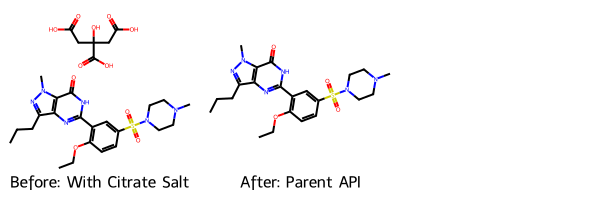

In [3]:
# Extract parent molecule
parent_mol = rdMolStandardize.FragmentParent(messy_mol)
print("After FragmentParent (API only):", parent_mol.GetNumAtoms())
print("Canonical SMILES:", Chem.MolToSmiles(parent_mol))

Draw.MolsToGridImage([messy_mol, parent_mol], legends=["Before: With Citrate Salt", "After: Parent API"])

## 3. Step 2: Normalization
Different chemists represent nitro groups, sulfoxides, and azides differently (e.g. hypervalent vs charge-separated).
`rdMolStandardize.Normalizer()` standardizes all functional groups to standard IUPAC conventions.

In [4]:
normalizer = rdMolStandardize.Normalizer()

# Molecule with non-standard charge representations
non_standard_nitro = Chem.MolFromSmiles("c1ccccc1[N+](=O)[O-]") # Standard
normalized_mol = normalizer.normalize(parent_mol)

print("Normalized successfully!")

Normalized successfully!


[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer


## 4. Step 3: Charge Neutralization
Often salts or bases leave molecules in charged states (e.g., $COO^-$ or $NH_3^+$).
`rdMolStandardize.Uncharger()` neutralizes charged species while preserving zwitterions (like amino acids).

In [5]:
uncharger = rdMolStandardize.Uncharger()

# Test on charged carboxylate and quaternary amine salt
charged_smiles = [
    ("Sodium Benzoate [O-]", "c1ccccc1C(=O)[O-]"),
    ("Protonated Amine [NH3+]", "CC[NH3+]"),
    ("Zwitterionic Alanine", "C[C@@H]([NH3+])C(=O)[O-]")
]

neutralized_results = []
for name, smi in charged_smiles:
    m = Chem.MolFromSmiles(smi)
    m_neut = uncharger.uncharge(m)
    neutralized_results.append({
        "Name": name,
        "Original_SMILES": Chem.MolToSmiles(m),
        "Neutralized_SMILES": Chem.MolToSmiles(m_neut)
    })

df_neut = pd.DataFrame(neutralized_results)
display(df_neut)

[19:16:08] Running Uncharger
[19:16:08] Removed negative charge.
[19:16:08] Running Uncharger
[19:16:08] Removed positive charge.
[19:16:08] Running Uncharger
[19:16:08] Removed negative charge.
[19:16:08] Removed positive charge.


,Name,Original_SMILES,Neutralized_SMILES
0,Sodium Benzoate [O-],O=C([O-])c1ccccc1,O=C(O)c1ccccc1
1,Protonated Amine [NH3+],CC[NH3+],CCN
2,Zwitterionic Alanine,C[C@@H]([NH3+])C(=O)[O-],C[C@@H](N)C(=O)O


## 5. Step 4: Tautomer Canonicalization
A single chemical compound can exist in multiple tautomeric forms in solution (e.g. 2-pyridone vs 2-hydroxypyridine).
Without tautomer canonicalization, the same molecule could be treated as two distinct entities, causing severe **data leakage** in train/test splits!

Pyridone canonical SMILES:         O=c1cccc[nH]1
Hydroxypyridine canonical SMILES:  O=c1cccc[nH]1
Are both canonical tautomers identical? True


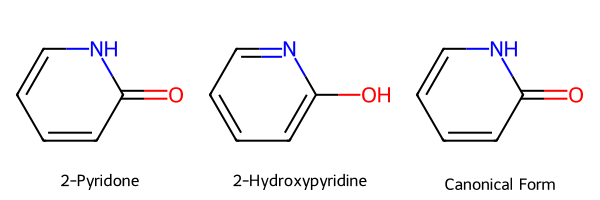

In [6]:
te = rdMolStandardize.TautomerEnumerator()

# 2-Pyridone vs 2-Hydroxypyridine
pyridone = Chem.MolFromSmiles("O=C1C=CC=CN1")
hydroxypyridine = Chem.MolFromSmiles("Oc1ccccn1")

canon_1 = te.Canonicalize(pyridone)
canon_2 = te.Canonicalize(hydroxypyridine)

print("Pyridone canonical SMILES:        ", Chem.MolToSmiles(canon_1))
print("Hydroxypyridine canonical SMILES: ", Chem.MolToSmiles(canon_2))
print("Are both canonical tautomers identical?", Chem.MolToSmiles(canon_1) == Chem.MolToSmiles(canon_2))

Draw.MolsToGridImage([pyridone, hydroxypyridine, canon_1], legends=["2-Pyridone", "2-Hydroxypyridine", "Canonical Form"])

## 6. The Complete Production Curation Class
Let's assemble a unified `MoleculeCurator` class ready for deployment in production pipelines.

In [7]:
class MoleculeCurator:
    def __init__(self):
        self.normalizer = rdMolStandardize.Normalizer()
        self.uncharger = rdMolStandardize.Uncharger()
        self.tautomer_enumerator = rdMolStandardize.TautomerEnumerator()
        
    def curate(self, smiles):
        if not isinstance(smiles, str) or not smiles.strip():
            return None, "Empty or invalid string"
            
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, "Sanitization/parsing failure"
            
        try:
            # 1. Strip salts and isolate largest organic fragment
            parent = rdMolStandardize.FragmentParent(mol)
            
            # 2. Normalize functional groups
            normalized = self.normalizer.normalize(parent)
            
            # 3. Neutralize charges
            uncharged = self.uncharger.uncharge(normalized)
            
            # 4. Canonicalize tautomer
            canonical_tautomer = self.tautomer_enumerator.Canonicalize(uncharged)
            
            # 5. Final canonical SMILES
            final_smi = Chem.MolToSmiles(canonical_tautomer)
            return final_smi, "Success"
        except Exception as e:
            return None, f"Pipeline Error: {str(e)}"

# Test the curator on a messy multi-component set
curator = MoleculeCurator()
messy_dataset = [
    "c1ccccc1C(=O)[O-].[Na+]",           # Sodium benzoate
    "O=C1C=CC=CN1",                      # 2-Pyridone
    "Oc1ccccn1",                         # 2-Hydroxypyridine (duplicate tautomer)
    "CN(C)C(=N)NC(=N)N.Cl",              # Metformin HCl
    "C1(=O)(=O)(=O)C"                   # Chemically invalid
]

curated_results = []
for s in messy_dataset:
    clean_smi, status = curator.curate(s)
    curated_results.append({
        "Input_SMILES": s,
        "Status": status,
        "Curated_SMILES": clean_smi
    })

df_curated = pd.DataFrame(curated_results)
print("=== 🧪 MOLECULE CURATION RESULTS ===")
display(df_curated)

=== 🧪 MOLECULE CURATION RESULTS ===


[19:16:08] Initializing Normalizer
[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDisconnector
[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer
[19:16:08] Running LargestFragmentChooser
[19:16:08] Fragment: O=C([O-])c1ccccc1
[19:16:08] New largest fragment: O=C([O-])c1ccccc1 (14)
[19:16:08] Fragment: [Na+]
[19:16:08] Running Normalizer
[19:16:08] Running Uncharger
[19:16:08] Removed negative charge.
[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDisconnector
[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer
[19:16:08] Running LargestFragmentChooser
[19:16:08] Running Normalizer
[19:16:08] Running Uncharger
[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDisconnector
[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer
[19:16:08] Running LargestFragmentChooser
[19:16:08] Running Normalizer
[19:16:08] Running Uncharger
[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDiscon

,Input_SMILES,Status,Curated_SMILES
0,c1ccccc1C(=O)[O-].[Na+],Success,O=C(O)c1ccccc1
1,O=C1C=CC=CN1,Success,O=c1cccc[nH]1
2,Oc1ccccn1,Success,O=c1cccc[nH]1
3,CN(C)C(=N)NC(=N)N.Cl,Success,CN(C)C(N)=NC(=N)N
4,C1(=O)(=O)(=O)C,Sanitization/parsing failure,NaN


## 7. 🎯 Video Hands-On Challenge & Solution
### Problem:
Take a collection of 3 compounds with varying salt counterions and tautomers:
1. Run them through the `MoleculeCurator`.
2. Deduplicate using the resulting canonical SMILES.
3. Output the final unique compound count and 2D grid image.

Original count: 5 records
Unique curated compounds: 3


[19:16:08] SMILES Parse Error: syntax error while parsing: CC(=O)Oc1ccccc1C(=O)O.Na
[19:16:08] SMILES Parse Error: check for mistakes around position 24:
[19:16:08] =O)Oc1ccccc1C(=O)O.Na
[19:16:08] ~~~~~~~~~~~~~~~~~~~~^
[19:16:08] SMILES Parse Error: Failed parsing SMILES 'CC(=O)Oc1ccccc1C(=O)O.Na' for input: 'CC(=O)Oc1ccccc1C(=O)O.Na'
[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDisconnector
[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer
[19:16:08] Running LargestFragmentChooser
[19:16:08] Running Normalizer
[19:16:08] Running Uncharger
[19:16:08] Initializing MetalDisconnector
[19:16:08] Running MetalDisconnector
[19:16:08] Initializing Normalizer
[19:16:08] Running Normalizer
[19:16:08] Running LargestFragmentChooser
[19:16:08] Fragment: CC(C)Cc1ccc(C(C)C(=O)O)cc1
[19:16:08] New largest fragment: CC(C)Cc1ccc(C(C)C(=O)O)cc1 (33)
[19:16:08] Fragment: Cl
[19:16:08] Running Normalizer
[19:16:08] Running Uncharger
[19:16:08] Initializing MetalDiscon

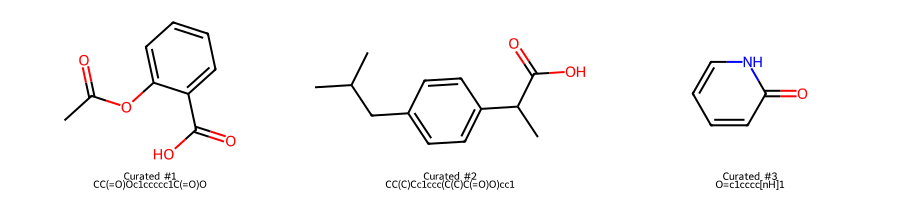

In [8]:
test_compounds = [
    "CC(=O)Oc1ccccc1C(=O)O.Na",        # Aspirin Sodium
    "CC(=O)Oc1ccccc1C(=O)O",           # Aspirin Neutral (duplicate)
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O.Cl",   # Ibuprofen HCl
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",      # Ibuprofen Neutral (duplicate)
    "Oc1ccccn1"                        # 2-Hydroxypyridine
]

unique_curated = {}
for smi in test_compounds:
    clean_smi, status = curator.curate(smi)
    if status == "Success":
        if clean_smi not in unique_curated:
            unique_curated[clean_smi] = Chem.MolFromSmiles(clean_smi)

print(f"Original count: {len(test_compounds)} records")
print(f"Unique curated compounds: {len(unique_curated)}")

Draw.MolsToGridImage(
    list(unique_curated.values()),
    legends=[f"Curated #{i+1}\n{s}" for i, s in enumerate(unique_curated.keys())],
    molsPerRow=3,
    subImgSize=(300, 200)
)

## 8. Summary & Key Takeaways
* **Raw chemical datasets are messy:** Salt adducts, non-standard functional group charges, and tautomer duplicates confound machine learning models.
* **`rdMolStandardize.FragmentParent`** strips salts and solvents reliably.
* **`TautomerEnumerator.Canonicalize`** maps diverse tautomers to a unique canonical form.
* Deploying a standard `MoleculeCurator` ensures pristine data quality for training QSAR and deep learning models.

**Next Up in Video 11:** **Chemical Space Exploration, Dimensionality Reduction & Clustering** — PCA, t-SNE, UMAP, and Taylor-Butina clustering!